**Notebook ต้อง<br>**
อธิบายปัญหาและเป้าหมายของโครงการ<br>
ระบุแหล่งที่มาและอธิบายชุดข้อมูล<br>
สำรวจและเตรียมข้อมูล<br>
แบ่งข้อมูลสำหรับฝึกและทดสอบ โดยไม่ใช้ชุดทดสอบในการฝึกหรือปรับเลือกแบบจำลอง<br>
ฝึกแบบจำลองพร้อมอธิบายเหตุผลที่เลือกวิธีนั้น<br>
ประเมินผลบนชุดทดสอบและแปลความหมายของเมตริก<br>
แสดงตัวอย่างผลทำนายและวิเคราะห์ข้อผิดพลาด<br>
บันทึกแบบจำลองเพื่อนำไปใช้ในเว็บแอป<br>

Notebook ต้องมีคำอธิบายประกอบและสามารถรันตามลำดับได้



# 03603351 Introduction to Data Science
---
## โครงการทำนายค่าเบี้ยประกันสุขภาพ (Medical Insurance Cost Prediction)
* **ปัญหา**
ค่ารักษาพยาบาลของแต่ละคนต่างกันมาก บริษัทประกันและผู้วางแผนการเงินจึงต้องการ **ประเมินค่ารักษาที่คาดว่าจะเกิดขึ้นต่อคนต่อปี** จากข้อมูลพื้นฐานที่หาได้ง่าย

* **เป้าหมาย (Objective):** พัฒนาแบบจำลอง Regression เพื่อทำนายค่าเบี้ยประกันสุขภาพรายบุคคลในสหรัฐอเมริกา <br>
* **สิ่งที่ต้องการทำนาย (Target)**
| รายการ | รายละเอียด |
|---|---|
| ตัวแปรเป้าหมาย | `charges` — ค่ารักษาพยาบาลรายปีของบุคคลหนึ่งคนที่เรียกเก็บผ่านประกันสุขภาพ |
| หน่วย | **ดอลลาร์สหรัฐ (USD) ต่อปี** |
| ชนิด | ตัวเลขต่อเนื่อง จึงเป็นปัญหา Regression |
> **หมายเหตุเรื่องคำศัพท์:** `charges` คือ *ค่ารักษาที่เรียกเก็บ* ซึ่งไม่ใช่ *เบี้ยประกัน (premium)* โดยตรง แบบจำลองนี้ทำนายต้นทุนที่คาดว่าจะเกิด ซึ่งเป็นข้อมูลประกอบการตั้งเบี้ยได้ แต่ไม่ได้ทำนายราคาเบี้ยที่บริษัทประกันเรียกเก็บ

* **ตัวแปรนำเข้า (Input Features):**
  1. `age`: อายุของผู้รับประกัน (ปี)
  2. `sex`: เพศ (`male`, `female`)
  3. `bmi`: ดัชนีมวลกาย ($kg/m^2$)
  4. `children`: จำนวนบุตรหรือผู้อยู่ในความดูแล
  5. `smoker`: สถานะการสูบบุหรี่ (`yes`, `no`)
  6. `region`: ภูมิภาคที่อยู่อาศัยในสหรัฐฯ (`northeast`, `northwest`, `southeast`, `southwest`)
* **การนำไปใช้ประโยชน์:**
  * **บริษัทประกัน:** ช่วยประเมินความเสี่ยงและคำนวณเบี้ยประกันรายบุคคลได้อย่างแม่นยำ สมเหตุสมผล และรวดเร็ว
  * **ผู้เอาประกัน/บุคคลทั่วไป:** ช่วยประเมินและวางแผนค่าใช้จ่ายด้านสุขภาพล่วงหน้าตามปัจจัยเสี่ยงของตนเอง
*   ผลลัพธ์สำคัญ (Key Result) :
| เมตริก | ค่าบนชุดทดสอบ |
|---|---|
| **MAE (เมตริกหลัก)** | **2,756.90 USD** ≈ 21\% ของค่ารักษาเฉลี่ย (12,973 USD) |
| RMSE | 4,573.81 USD |
| R² | 86.52\% |

### เลือกเมตริกอย่างไร
**เมตริกหลักคือ MAE (Mean Absolute Error)** มีหน่วยเป็น USD ตรงกับสิ่งที่ต้องการทำนายจึงอธิบายให้ผู้ใช้เข้าใจได้ทันทีว่า "ทำนายพลาดเฉลี่ยกี่ดอลลาร์" และไม่ถูกดึงไปมากนักโดยแถวที่ค่าสูงผิดปกติเพียงไม่กี่แถว<br>
ใช้ **RMSE** (ลงโทษความผิดพลาดใหญ่หนักกว่า) และ **R²** (สัดส่วนความแปรปรวนที่อธิบายได้) เป็นเมตริกประกอบ

---
## แหล่งที่มาและคำอธิบายชุดข้อมูล
* **แหล่งที่มา:** Kaggle — *Medical Cost Personal Datasets* (ผู้เผยแพร่ mirichoi0218) https://www.kaggle.com/datasets/mirichoi0218/insurance
* **ไฟล์:** `insurance.csv` — 1 แถว = บุคคล 1 คน
* **ขนาดข้อมูลดิบ:** 1,338 แถว × 7 คอลัมน์
* **ข้อควรระวัง:** ชุดข้อมูลนี้เหมาะกับการเรียนรู้ ไม่ได้ระบุปีที่เก็บข้อมูล และไม่มีตัวแปรสุขภาพสำคัญ เช่น โรคประจำตัว ผลจึงนำไปสรุปกับประชากรจริงไม่ได้ทั้งหมด

| คอลัมน์ | ความหมาย | ชนิด | ค่าที่เป็นไปได้ |
|---|---|---|---|
| `age` | อายุของผู้เอาประกัน (ปี) | ตัวเลขจำนวนเต็ม | ช่วงที่พบในข้อมูล 18–64 |
| `sex` | เพศ | หมวดหมู่ | `male`, `female` |
| `bmi` | ดัชนีมวลกาย (กก./ม.²) | ตัวเลขทศนิยม | BMI ≥ 30 ถือว่าอยู่ในเกณฑ์อ้วน |
| `children` | จำนวนบุตรที่อยู่ในความดูแลตามกรมธรรม์ | ตัวเลขจำนวนเต็ม | 0–5 |
| `smoker` | สูบบุหรี่หรือไม่ | หมวดหมู่ | `yes`, `no` |
| `region` | ภูมิภาคที่อยู่อาศัยในสหรัฐฯ | หมวดหมู่ | `northeast`, `northwest`, `southeast`, `southwest` |
| **`charges`** | **ค่ารักษาพยาบาลรายปี (USD) — ตัวแปรเป้าหมาย** | ตัวเลขทศนิยม | > 0 |

In [ ]:
# install required libraries
# ใน colab ไม่จำเป็น

# !pip install gradio
# !pip install numpy
# !pip install pandas
# !pip install scikit-learn
# !pip install ipywidgets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np
import joblib
import gradio as gr

##0.โหลดข้อมูล

In [ ]:
try:
    df = pd.read_csv("insurance.csv")
except FileNotFoundError:
    raise FileNotFoundError("ไม่พบ insurance.csv — กรุณาวางไฟล์ไว้โฟลเดอร์เดียวกับ notebook (บน Colab ให้อัปโหลดไฟล์ก่อน)")

---
##1.ตรวจข้อมูลที่นำมาใช้

###1.1 ดูว่า Type ตรงไหม (ตรง)
เลขต้องเป็นพวกint/float ไม่ใช่ str/object

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


###1.2 ดูว่ามี null ไหม (ไม่มี)
จริงๆจะดูที่ Non-Null Count ของ .info() ก็ได้ <br>
ถ้า count < entries(rows) = มี null<br>
<br>
แต่จะดูยากกว่า!

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


###1.3ตรวจสอบข้อมูลซ้ำซ้อน (มี แต่ก็เป็นไปได้ เพราะ เราไม่ได้เก็บ ID)

ตัวอย่างโค้ดตรวจสอบ<br>

ตรวจ?

*   ซ้ำข้อมูลทุก columns `exact_dups = df.duplicated().sum()`
*   ซ้ำ ID `key_dups = df[df.duplicated(subset=['student_id'], keep=False)]`

In [ ]:
n_dup = df.duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรกที่พบ): {n_dup} แถว")

df[df.duplicated(keep=False)]


จำนวนแถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรกที่พบ): 1 แถว


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**การตัดสินใจ:** ลบแถวที่ซ้ำ เพราะทั้ง 7 คอลัมน์ตรงกัน รวมถึง `charges` ที่มีทศนิยมหลายตำแหน่ง ซึ่งโอกาสตรงกันโดยบังเอิญต่ำมาก
เหตุผลสำคัญกว่าจำนวนที่ลบ (เพียง 1 แถว) คือ **ป้องกันไม่ให้แถวเดียวกันตกอยู่ทั้งชุดฝึกและชุดทดสอบ** ซึ่งทำให้ผลประเมินดูดีเกินจริง

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"ก่อนลบ {len(df_raw):,} แถว -> หลังลบ {len(df):,} แถว")

ก่อนลบ 1,338 แถว -> หลังลบ 1,337 แถว


###1.4 ตรวจสอบค่าผิดปกติ (Outliers Detection) (มีบ้างแต่ยังเป็นไปได้)

In [ ]:
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [ ]:
rows_count=len(df)
def check_all_outliers(df, cols=None):
    # ถ้าไม่ได้ระบุคอลัมน์ ให้เลือกคอลัมน์ที่เป็นตัวเลขทั้งหมดใน df
    if cols is None:
        cols = df.select_dtypes(include=['number']).columns

    for col in cols:
        outliers, low, high = find_outliers_iqr(df, col)
        count = len(outliers)
        percent = (count / rows_count) * 100

        print(f"ช่วงปกติของ {col}: [{low:.2f}, {high:.2f}]")
        print(f"พบ Outliers ใน {col} จำนวน {count} รายการ ({percent:.2f}%):")
        if count > 0:
            print(outliers[[col]])
        print("-" * 40)


In [ ]:
check_all_outliers(df, ['age'])

ช่วงปกติของ age: [-9.00, 87.00]
พบ Outliers ใน age จำนวน 0 รายการ (0.00%):
----------------------------------------


In [ ]:
check_all_outliers(df, ['children'])

ช่วงปกติของ children: [-3.00, 5.00]
พบ Outliers ใน children จำนวน 0 รายการ (0.00%):
----------------------------------------


In [ ]:
check_all_outliers(df, ['bmi'])

ช่วงปกติของ bmi: [13.67, 47.32]
พบ Outliers ใน bmi จำนวน 9 รายการ (0.67%):
        bmi
116   49.06
286   48.07
401   47.52
543   47.41
846   50.38
859   47.60
1046  52.58
1087  47.74
1316  53.13
----------------------------------------


In [ ]:
check_all_outliers(df, ['charges'])

ช่วงปกติของ charges: [-13120.72, 34524.78]
พบ Outliers ใน charges จำนวน 139 รายการ (10.40%):
          charges
14    39611.75770
19    36837.46700
23    37701.87680
29    38711.00000
30    35585.57600
...           ...
1299  62592.87309
1300  46718.16325
1302  37829.72420
1312  36397.57600
1322  43896.37630

[139 rows x 1 columns]
----------------------------------------


**การตัดสินใจ: เก็บ outlier ไว้ทั้งหมด**
* `charges` สูงมากมักเป็นผู้สูบบุหรี่ที่ BMI สูง ซึ่งเป็นกลุ่มที่แบบจำลองต้องทำนายให้ได้ ไม่ใช่ข้อมูลผิด
* `bmi` สูงถึงราว 50 เป็นไปได้ในทางการแพทย์ และ `children` ไม่มีค่าที่เกินจริง
* การลบจะทำให้แบบจำลองมองไม่เห็นกรณีรุนแรงที่ผู้ใช้จริงอาจเจอ

###1.5 ตรวจ business logic ผิด (ไม่มี)


*   age, bmi, children, charges ห้ามติดลบ

ตัวอย่างอื่นๆ เช่น คะแนนห้ามเกิน100



In [ ]:
# (ข) กติกาทางธุรกิจ: นับจำนวนแถวที่ผิดกติกา
rules = {
    "age อยู่ในช่วง 0-120":            ~df["age"].between(0, 120),
    "bmi อยู่ในช่วง 10-80":            ~df["bmi"].between(10, 80),
    "children ไม่ติดลบและเป็นจำนวนเต็ม": (df["children"] < 0) | (df["children"] % 1 != 0),
    "charges มากกว่า 0":               df["charges"] <= 0,
}
print()
for name, violated in rules.items():
    print(f"{name:34s}: ผิดกติกา {int(violated.sum())} แถว")


age อยู่ในช่วง 0-120              : ผิดกติกา 0 แถว
bmi อยู่ในช่วง 10-80              : ผิดกติกา 0 แถว
children ไม่ติดลบและเป็นจำนวนเต็ม : ผิดกติกา 0 แถว
charges มากกว่า 0                 : ผิดกติกา 0 แถว


###1.6 ตรวจค่าเปลก

*   smoker ไม่ใช่ yes/no
*   sex ไม่ใช่ male/female
*   region ไม่ใช่ northEast/northWest/southEast/southWest



In [ ]:
# ทาง1 ดึงแถวที่ค่าไม่อยู่ในรายการที่ถูกต้อง (Case-sensitive)
df[~df['smoker'].isin(['yes', 'no']) | ~df['sex'].isin(['male', 'female']) | ~df['region'].isin(['northeast', 'northwest', 'southeast', 'southwest'])]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
#ตัวอย่างกรณีกรองเจอ
df[~df['smoker'].isin(['no'])].head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768


In [ ]:
# ทาง2 พิมพ์ค่า Unique ของทั้ง 3 คอลัมน์ออกมาดู
#แล้วกวาดตามอง
for col in ['smoker', 'sex', 'region']: print(f"{col}: {df[col].unique().tolist()}")

smoker: ['yes', 'no']
sex: ['female', 'male']
region: ['southwest', 'southeast', 'northwest', 'northeast']


**สรุป:** ข้อมูลไม่มีค่าว่าง ชนิดข้อมูลถูกต้อง ไม่มีค่าผิดกติกา มีแถวซ้ำ 1 แถวที่ลบออกแล้ว จึงไม่ต้องทำความสะอาดเพิ่ม

---
##2.ทำความสะอาดข้อมูล หรือ เปลี่ยนชุดข้อมูล/หาข้อมูลใหม่(ถ้าเกินเยียวยา)

ข้อมูลที่นำมาใช้ครั้งนี้ไม่มีอะไรต้องแก้

---
## 3.สำรวจข้อมูล (EDA)

### ลักษณะของตัวแปรเป้าหมาย `charges`

count     1337.00
mean     13279.12
std      12110.36
min       1121.87
25%       4746.34
50%       9386.16
75%      16657.72
max      63770.43
Name: charges, dtype: float64

ความเบ้ (skewness) ของ charges = 1.52  (0 = สมมาตร, มากกว่า 1 = เบ้ขวาชัดเจน)


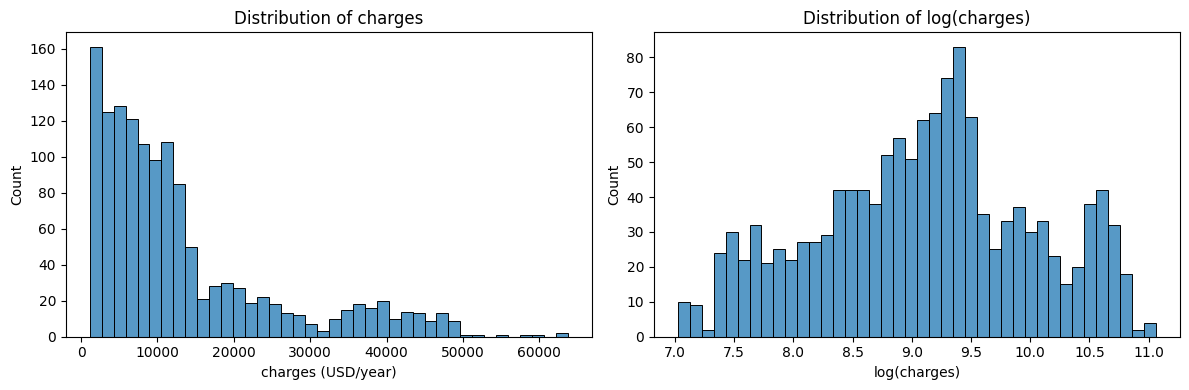

In [ ]:
print(df["charges"].describe().round(2))
print(f"\nความเบ้ (skewness) ของ charges = {df['charges'].skew():.2f}  (0 = สมมาตร, มากกว่า 1 = เบ้ขวาชัดเจน)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], bins=40, ax=axes[0])
axes[0].set_title("Distribution of charges")
axes[0].set_xlabel("charges (USD/year)")
sns.histplot(np.log(df["charges"]), bins=40, ax=axes[1])
axes[1].set_title("Distribution of log(charges)")
axes[1].set_xlabel("log(charges)")
plt.tight_layout()
plt.show()

charges เบ้ขวา: คนส่วนใหญ่มีค่ารักษาต่ำ และมีกลุ่มเล็ก ๆ ที่สูงมาก ซึ่งส่งผลต่อ RMSE/R² มากกว่า MAE

---
##4.CDA,Confirmatory Data Analysis, "การวิเคราะห์ข้อมูลเชิงยืนยัน"
คือการตรวจสอบสมมติฐานหรือทฤษฎีที่เรามีอยู่แล้ว<br>
เพื่อดูว่าข้อมูลจริงที่เก็บมานั้น "ตรงและยืนยัน" ความเชื่อของเราหรือไม่

###4.1 ตั้งสมมุติฐาน
ในข้อมูล มี6ตัวแปรต้น ตั้งสมมุติฐานให้แต่ละตัวแปรได้ดังนี้ได้แก่

*   age อายุ = ยิ่งอายุมาก ยิ่งแพง
*   *sex เพศ = ไม่น่าส่งผล?
*   bmi	= ยิ่งอ้วน ยิ่งแพง
*   *children จำนวนลูก = ไม่น่าส่งผล?
*   smoker = ถ้าสูบ น่าจะแพงมาก
*   region ภาค = ไม่น่าส่งผล?


###4.2 ตรวจสมมติฐานด้วยกราฟ

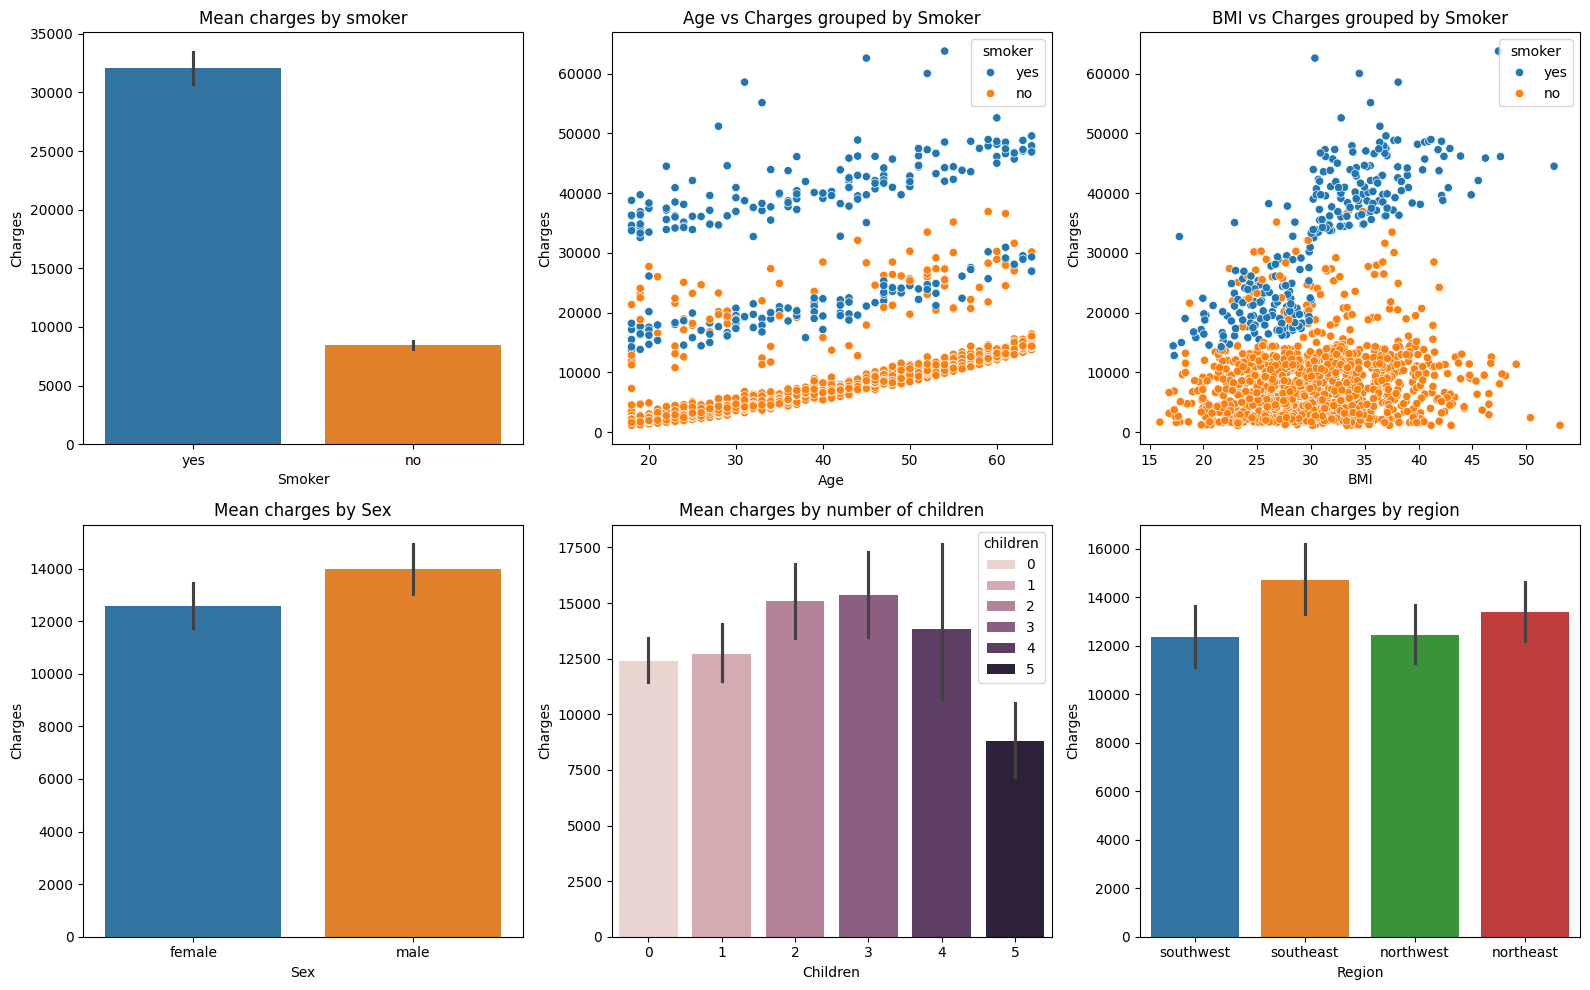

In [ ]:
%matplotlib inline

# สร้าง Figure ขนาดรวมที่มี 1 แถว 2 คอลัมน์
fig, ((ax1, ax2,ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 10))

sns.barplot(x="smoker", y="charges", hue="smoker", data=df, ax=ax1)
ax1.set_title("Mean charges by smoker")
ax1.set_xlabel("Smoker")
ax1.set_ylabel("Charges")

sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=ax2)
ax2.set_title("Age vs Charges grouped by Smoker")
ax2.set_xlabel("Age")
ax2.set_ylabel("Charges")

sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=ax3)
ax3.set_title("BMI vs Charges grouped by Smoker")
ax3.set_xlabel("BMI")
ax3.set_ylabel("Charges")

sns.barplot(x="sex", y="charges", hue="sex",data=df, ax=ax4)
ax4.set_title("Mean charges by Sex")
ax4.set_xlabel("Sex")
ax4.set_ylabel("Charges")

sns.barplot(x="children", y="charges",hue="children", data=df, ax=ax5)
ax5.set_title("Mean charges by number of children")
ax5.set_xlabel("Children")
ax5.set_ylabel("Charges")

sns.barplot(x="region", y="charges",hue="region", data=df, ax=ax6)
ax6.set_title("Mean charges by region")
ax6.set_xlabel("Region")
ax6.set_ylabel("Charges")

# ปรับระยะห่างระหว่างกราฟไม่ให้ข้อความทับกัน
plt.tight_layout()
plt.show()

In [ ]:
# ตัวเลขประกอบกราฟ: ค่าเฉลี่ย charges แยกตามกลุ่ม
for col in ["smoker", "sex", "region", "children"]:
    print(df.groupby(col)["charges"].agg(["count", "mean"]).round(0).rename(columns={"count": "n", "mean": "mean charges"}))
    print()

           n  mean charges
smoker                    
no      1063        8441.0
yes      274       32050.0

          n  mean charges
sex                      
female  662       12570.0
male    675       13975.0

             n  mean charges
region                      
northeast  324       13406.0
northwest  324       12451.0
southeast  364       14735.0
southwest  325       12347.0

            n  mean charges
children                   
0         573       12385.0
1         324       12731.0
2         240       15074.0
3         157       15355.0
4          25       13851.0
5          18        8786.0



จากสมมุติฐาน
*   age อายุ = ยิ่งอายุมาก ยิ่งแพง
*   *sex เพศ = ไม่น่าส่งผล?
*   bmi	= ยิ่งอ้วน ยิ่งแพง
*   *children จำนวนลูก = ไม่น่าส่งผล?
*   smoker = ถ้าสูบ น่าจะแพงมาก
*   region ภาค = ไม่น่าส่งผล?

จากกราฟจะเห็นว่า age,bmi เป็นไปตามสมมุติฐานที่ตั้งไว้ คือ ยิ่งมากยิ่งแพง


### กราฟเหล่านี้ยังหลอกตาได้: ตัวแปรกวน (confounding)
ค่าเฉลี่ย `charges` ของเพศชายอาจสูงกว่า แต่ต้องดูก่อนว่าเป็นเพราะ **เพศ** หรือเพราะ **สัดส่วนผู้สูบบุหรี่ในแต่ละเพศต่างกัน**

In [ ]:
smoke_by_sex = pd.crosstab(df["sex"], df["smoker"])
smoke_by_sex["สัดส่วนผู้สูบ (%)"] = (smoke_by_sex["yes"] / smoke_by_sex.sum(axis=1) * 100).round(1)
print(smoke_by_sex)

print("\nค่าเฉลี่ย charges แยกตาม เพศ และ การสูบบุหรี่:")
print(df.pivot_table(index="sex", columns="smoker", values="charges", aggfunc="mean").round(0))

smoker   no  yes  สัดส่วนผู้สูบ (%)
sex                                
female  547  115               17.4
male    516  159               23.6

ค่าเฉลี่ย charges แยกตาม เพศ และ การสูบบุหรี่:
smoker      no      yes
sex                    
female  8762.0  30679.0
male    8100.0  33042.0


เพศชายมีสัดส่วนผู้สูบบุหรี่สูงกว่า (23.6% เทียบกับ 17.4%) ซึ่งดึงค่าเฉลี่ยรวมของเพศชายให้สูงขึ้น<br>
เมื่อแยกตามการสูบบุหรี่จะเห็นว่า **ผลของเพศโดยตรงเล็กและทิศทางไม่คงที่:** ในกลุ่มผู้ไม่สูบ หญิงสูงกว่าชายเล็กน้อย (8,964 เทียบกับ 8,169 USD) <br>
ส่วนในกลุ่มผู้สูบ ชายสูงกว่า (~33,000 เทียบกับ ~31,000 USD)

### ปฏิสัมพันธ์ระหว่าง BMI และการสูบบุหรี่
ตัวแปร `bmi` มีผลต่อ `charges` ต่างกันตามการสูบบุหรี่ ลองดูแยกกลุ่มพร้อมเส้นแบ่งที่ BMI = 30 (เกณฑ์อ้วน)

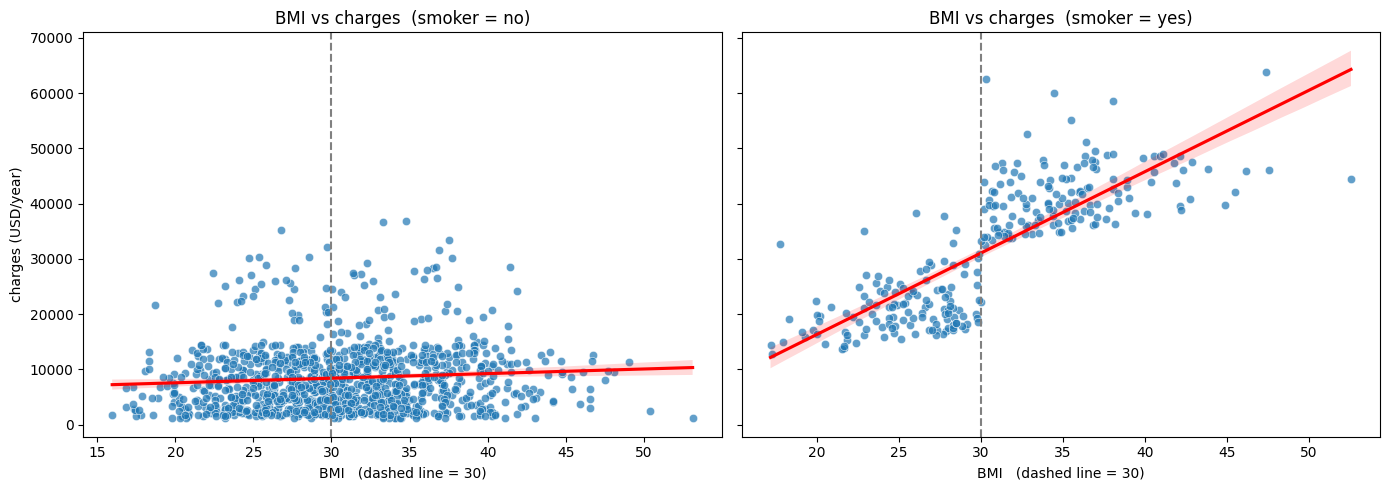

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (status, part) in zip(axes, df.groupby("smoker")):
    sns.scatterplot(data=part, x="bmi", y="charges", alpha=0.7, ax=ax)
    sns.regplot(data=part, x="bmi", y="charges", scatter=False, color="red", ax=ax)
    ax.axvline(30, color="gray", linestyle="--")
    ax.set_title(f"BMI vs charges  (smoker = {status})")
    ax.set_xlabel("BMI   (dashed line = 30)")
    ax.set_ylabel("charges (USD/year)")
plt.tight_layout()
plt.show()

### 4.3 สรุปผลการตรวจสมมติฐาน
| ตัวแปร | สมมติฐาน | ผลจากข้อมูล |
|---|---|---|
| `smoker` | ส่งผลมาก | **เป็นไปตามคาด** ผู้สูบบุหรี่มีค่าเฉลี่ยสูงกว่าหลายเท่า และเป็นตัวแปรที่แยกกลุ่มได้ชัดที่สุด |
| `age` | อายุมาก → แพง | **เป็นไปตามคาด** ค่ารักษาเพิ่มตามอายุ และเห็นเป็น 3 แถบ: แถบล่างเป็นผู้ไม่สูบเกือบทั้งหมดและเพิ่มเป็นเส้นตรงตามอายุ แถบกลางมีทั้งผู้สูบและไม่สูบปนกัน แถบบนเป็นผู้สูบ |
| `bmi` | BMI สูง → แพง | **เป็นจริงบางส่วน** ในผู้ไม่สูบบุหรี่แทบไม่เห็นแนวโน้ม แต่ในผู้สูบบุหรี่ที่ BMI ≥ 30 ค่ารักษากระโดดขึ้นชัดเจน จึงเป็น *ปฏิสัมพันธ์* ระหว่าง `bmi` กับ `smoker` |
| `sex` | ไม่น่าส่งผล | **ผลเล็กและไม่คงที่** ชายสูงกว่าหญิงเล็กน้อยโดยรวม ส่วนหนึ่งมาจากสัดส่วนผู้สูบบุหรี่ แต่เมื่อแยกกลุ่ม ทิศทางสลับกัน (หัวข้อ 6.4) |
| `children` | ไม่น่าส่งผล | **ผลไม่ชัดและไม่เป็นเส้นตรง** กลุ่ม 0–3 บุตรมีค่าเฉลี่ยราว 12,300–15,600 USD แต่กลุ่ม 4 และ 5 บุตรมีข้อมูลน้อยมาก (20 และ 9 ราย) แถบความคลาดเคลื่อนกว้าง จึงไม่ควรสรุปแนวโน้มจากกลุ่มนั้น |
| `region` | ไม่น่าส่งผล | **ผลเล็ก** ค่าเฉลี่ยของ 4 ภูมิภาคอยู่ระหว่างราว 12,300–14,800 USD ซึ่งต่างกันน้อยกว่าผลของการสูบบุหรี่ (ราว 8,600 เทียบกับ 31,900 USD) มาก |

**ข้อสรุปที่นำไปสร้างแบบจำลอง:** ความสัมพันธ์ไม่เป็นเส้นตรงแบบบวกกันธรรมดา มี 2 จุดที่ควรจัดการ คือ
* **ปฏิสัมพันธ์ `bmi × smoker`** และการกระโดดที่ BMI ≥ 30 ในกลุ่มผู้สูบบุหรี่

> หมายเหตุ: หัวข้อนี้เป็นการสำรวจด้วยกราฟและค่าเฉลี่ย ยังไม่ใช่การทดสอบสมมติฐานทางสถิติ (เช่น t-test) จึงใช้คำว่า "เห็นแนวโน้ม" ไม่ใช่ "พิสูจน์ได้"

---
##5.สร้างแบบจำลอง (Model training)


### ทำไมเลือก Linear Regression
| เหตุผล | อธิบาย |
|---|---|
| ตรงกับโจทย์ | เป้าหมายเป็นตัวเลขต่อเนื่อง (USD) |
| ข้อมูลมีขนาดเล็ก | ราว 1,300 แถว และมีตัวแปรไม่กี่ตัว โมเดลเชิงเส้นเรียบง่ายจึงไม่ overfit ง่ายเท่าโมเดลซับซ้อน |
| **อธิบายได้** | ค่าสัมประสิทธิ์บอกได้ว่าแต่ละปัจจัยเพิ่ม/ลดค่ารักษากี่ดอลลาร์ ซึ่งสำคัญในงานประกันที่ต้องชี้แจงเหตุผลได้ |
| เป็น baseline มาตรฐาน | ฝึกเร็ว ขนาดไฟล์เล็ก นำไปใช้ในเว็บแอปง่าย |

**ข้อจำกัด:** Linear Regression สมมติว่าแต่ละปัจจัยส่งผลแบบ "บวกกัน" ตามเส้นตรง แต่จากหัวข้อ 3 พบปฏิสัมพันธ์ `bmi × smoker`
จึงแก้ด้วย **การสร้างตัวแปรใหม่ (feature engineering)** แล้วเทียบทางเลือกด้วย cross-validation โดยยังคงใช้โมเดลเชิงเส้นที่อธิบายได้

###5.1 เทรนแบบทื่อๆ (อธิบาย code เต็มๆใน 5.2)

In [ ]:
# 0. โหลดข้อมูล
# 1. แปลงเป็น One-Hot Encoding
features = ["age", "sex", "bmi", "children", "smoker", "region"]
X = pd.get_dummies(df[features], drop_first=True)
y = df["charges"]

# 2. แบ่งข้อมูลเป็น Train และ Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. เทรนโมเดล
model = LinearRegression().fit(X_train, y_train)

# 4. แสดงผลลัพธ์
print("Train R^2 =", model.score(X_train, y_train))
print("Test R^2 =", model.score(X_test, y_test))

mean_charge = y_test.mean()

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Charge : ${mean_charge:,.2f}")
print(f"MAE : ${mae:,.2f} ({mae/mean_charge*100:.1f}%)")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : ${rmse:,.2f} ({rmse/mean_charge*100:.1f}%)")

print("\n--- Coefficients ---")
print(pd.Series(model.coef_, index=X.columns))

Train R^2 = 0.7299057809339075
Test R^2 = 0.8069287081198011
Mean Charge : $14,272.01
MAE : $4,177.05 (29.3%)
RMSE : $5,956.34 (41.7%)

--- Coefficients ---
age                   248.210720
bmi                   318.701441
children              533.009989
sex_male             -101.542054
smoker_yes          23077.764593
region_northwest     -391.761455
region_southeast     -838.919616
region_southwest     -659.139752
dtype: float64


จะเห็นว่าผลลัพธ์ของการเทรนทื่อๆ โยนทุกตัวแปรต้นเข้าไปตรงๆ ให้ผลออกมาดีในระดับหนึ่ง แต่ถ้าเอาความสัมพันธ์ bmi x smoker มาคิดด้วยล่ะ?

###5.2เทรนแบบมีชั้นเชิง

จำกราฟนี้ได้ไหม?

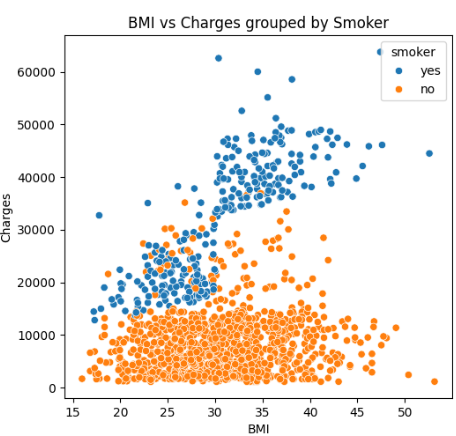

จะเห็นว่า bmi จะส่งผลต่อเบี้ยประกันมากกว่า "ถ้าสูบบุหรี่และอ้วน"

#### 5.2.1 การเตรียมตัวแปรก่อนฝึก

**One-Hot Encoding:** โมเดลรับได้เฉพาะตัวเลข จึงแปลงตัวแปรหมวดหมู่ (`sex`, `smoker`, `region`) เป็นคอลัมน์ 0/1 โดยใช้ `drop="first"` เพื่อตัดหนึ่งหมวดทิ้ง (หมวดที่ตัดจะเป็นค่าอ้างอิง) ไม่เช่นนั้นคอลัมน์จะซ้ำซ้อนกันเองและทำให้ค่าสัมประสิทธิ์ตีความยาก


In [ ]:

#1. แปลงเป็น One-Hot Encoding
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes')
features = ["age", "sex", "bmi", "children", "smoker", "region", "bmi_smoker"]
X = pd.get_dummies(df[features], drop_first=True)
y = df["charges"]

In [ ]:
X.head()

,age,bmi,children,bmi_smoker,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,27.9,False,True,False,False,True
1,18,33.770,1,0.0,True,False,False,True,False
2,28,33.000,3,0.0,True,False,False,True,False
3,33,22.705,0,0.0,True,False,True,False,False
4,32,28.880,0,0.0,True,False,True,False,False


####5.2.2 แบ่งข้อมูลเป็น แบบฝึกหัด และ ข้อสอบ

In [ ]:
# 2. แบ่งข้อมูลเป็น Train และ Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

####5.2.3 ฝึก model

In [ ]:
# 3. เทรนโมเดล
model = LinearRegression().fit(X_train, y_train)

**`.fit()`:** เป็นขั้น "เรียนรู้" ของโมเดล Linear Regression หาค่าสัมประสิทธิ์ที่ทำให้ผลรวมความคลาดเคลื่อนกำลังสองบนข้อมูลฝึกต่ำที่สุด (วิธี Ordinary Least Squares)

####5.2.4 ประเมิณ model และ แสดงผลลัพธ์

In [ ]:
# 4. ประเมิณ model และ แสดงผลลัพธ์
print("Train R^2 =", model.score(X_train, y_train))
print("Test R^2  =", model.score(X_test, y_test))

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mean_charge = y_test.mean()
print(f"Mean Charge : ${mean_charge:,.2f}")
print(f"MAE : ${mae:,.2f} ({mae/mean_charge*100:.1f}%)")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : ${rmse:,.2f} ({rmse/mean_charge*100:.1f}%)")

print("\n--- Coefficients ---")
print(pd.Series(model.coef_, index=X.columns))

Train R^2 = 0.8247283224158267
Test R^2  = 0.8862045574393045
Mean Charge : $14,272.01
MAE : $2,828.97 (19.8%)
RMSE : $4,572.81 (32.0%)

--- Coefficients ---
age                   259.044014
bmi                    12.491983
children              570.041605
bmi_smoker           1476.603942
sex_male             -647.366040
smoker_yes         -21687.830077
region_northwest     -438.161448
region_southeast     -895.669808
region_southwest     -884.564628
dtype: float64


###  เมตริกที่ใช้ประเมิน
| เมตริก | สูตรโดยย่อ | อ่านค่าอย่างไร |
|---|---|---|
| **MAE** | ค่าเฉลี่ยของ \|จริง − ทำนาย\| | ทำนายพลาดโดยเฉลี่ยกี่ USD ยิ่งน้อยยิ่งดี |
| **RMSE** | √ค่าเฉลี่ยของ (จริง − ทำนาย)² | คล้าย MAE แต่ยกกำลังสองก่อนเฉลี่ย จึง *ลงโทษความพลาดใหญ่หนักกว่า* |
| **R²** | 1 − (ความคลาดเคลื่อนของโมเดล ÷ ความคลาดเคลื่อนของการเดาด้วยค่าเฉลี่ย) | 1 = สมบูรณ์แบบ, 0 = ไม่ดีกว่าเดาค่าเฉลี่ย, ติดลบ = แย่กว่าเดาค่าเฉลี่ย |

**MAE vs RMSE:** RMSE จะมากกว่าหรือเท่ากับ MAE เสมอ ถ้าสองค่าห่างกันมาก แปลว่ามีบางแถวที่ทำนายพลาดมาก
ข้อมูลชุดนี้ `charges` เบ้ขวา RMSE จึงสูงกว่า MAE ชัดเจน

**ทำไม MAE เป็นเมตริกหลัก?:** <br>
(1) มีหน่วยเป็น USD อธิบายให้ผู้ใช้เข้าใจง่าย<br>
(2) ไม่ถูกแถวที่ค่าสูงผิดปกติเพียงไม่กี่แถวดึงมากเท่า RMSE<br>
<br>
RMSE ใช้ดูความเสี่ยงจากกรณีพลาดหนัก และ R² ใช้เทียบกับการเดาด้วยค่าเฉลี่ยทุกรอบ

### อธิบายความหมายของเมตริกประเมินผล
* **$R^2$ (Coefficient of Determination) = 0.8862 (88.62%):** แบบจำลองสามารถอธิบายความแปรปรวนของค่าเบี้ยประกันสุขภาพได้ประมาณ 86.52% บนชุดทดสอบที่ไม่เคยเห็นมาก่อน
* **MAE (Mean Absolute Error) = 2,828.97 USD:** โดยเฉลี่ยแล้ว การทำนายของโมเดลคลาดเคลื่อนไปจากค่าเบี้ยประกันจริงประมาณ $2,828.97
* **RMSE (Root Mean Squared Error) = 4,572.81 USD:** ให้ความสำคัญกับข้อผิดพลาดขนาดใหญ่ (Outliers) <br>
และเนื่องจากค่า RMSE สูงกว่า MAE พอสมควร แสดงว่ามีบางกลุ่มข้อมูลที่โมเดลทำนายคลาดเคลื่อนมากกว่าปกติ

---
##6.ตัวอย่างผลทำนายและการวิเคราะห์ข้อผิดพลาด

### 6.1 ตัวอย่างผลทำนาย (สุ่ม 10 รายจากชุดทดสอบ)

In [ ]:
analysis = df.loc[y_test.index].copy() # Filter df to only include test set rows
analysis["predicted"] = y_pred
analysis["error"] = analysis["predicted"] - analysis["charges"]       # บวก = ทำนายสูงเกินจริง, ลบ = ต่ำกว่าจริง
analysis["abs_error"] = analysis["error"].abs()
analysis["pct_error"] = analysis["error"] / analysis["charges"] * 100

cols = ["age", "sex", "bmi", "children", "smoker", "region", "charges", "predicted", "error", "pct_error"]
analysis.sample(10, random_state=42)[cols].round(1).reset_index(drop=True)

,age,sex,bmi,children,smoker,region,charges,predicted,error,pct_error
0,24,male,35.9,0,no,southeast,1986.9,3285.9,1299.0,65.4
1,39,female,26.3,2,no,northwest,7201.7,9297.3,2095.6,29.1
2,49,female,42.7,2,no,southeast,9800.9,11634.6,1833.8,18.7
3,25,male,25.7,0,no,southeast,2137.7,3418.5,1280.9,59.9
4,18,male,33.3,0,no,southeast,1135.9,1700.0,564.1,49.7
5,50,male,32.2,0,no,northwest,8835.3,10432.9,1597.6,18.1
6,57,male,18.3,0,no,northeast,11534.9,12511.1,976.2,8.5
7,44,female,20.2,1,yes,northeast,19594.8,18575.9,-1018.9,-5.2
8,31,female,31.1,0,no,northeast,4347.0,6582.3,2235.3,51.4
9,43,male,27.8,0,yes,southwest,37829.7,27479.9,-10349.8,-27.4


### 6.2 ภาพรวมของความคลาดเคลื่อน

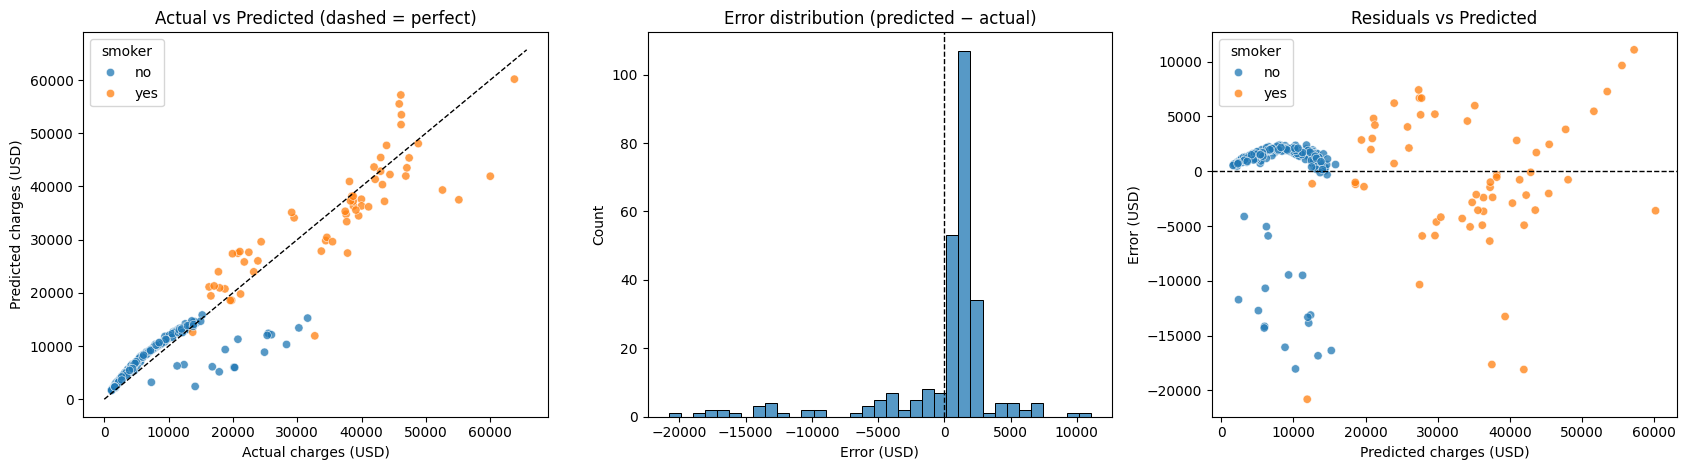

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.scatterplot(data=analysis, x="charges", y="predicted", hue="smoker", alpha=0.75, ax=axes[0])
lims = [0, max(analysis["charges"].max(), analysis["predicted"].max()) * 1.03]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_title("Actual vs Predicted (dashed = perfect)")
axes[0].set_xlabel("Actual charges (USD)")
axes[0].set_ylabel("Predicted charges (USD)")

sns.histplot(analysis["error"], bins=35, ax=axes[1])
axes[1].axvline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_title("Error distribution (predicted − actual)")
axes[1].set_xlabel("Error (USD)")

sns.scatterplot(data=analysis, x="predicted", y="error", hue="smoker", alpha=0.75, ax=axes[2])
axes[2].axhline(0, color="k", linestyle="--", linewidth=1)
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted charges (USD)")
axes[2].set_ylabel("Error (USD)")

plt.tight_layout()
plt.show()

### 6.3 ข้อผิดพลาดแยกตามกลุ่ม
แยกตามการสูบบุหรี่และเกณฑ์ BMI ≥ 30 เพื่อดูว่าแบบจำลองพลาดในกลุ่มไหนมากเป็นพิเศษ ดูทั้ง MAE (USD) และ MAE เป็น % ของค่ารักษาเฉลี่ยของกลุ่ม

In [ ]:
analysis["group"] = (
    np.where(analysis["smoker"] == "yes", "smoker", "non-smoker")
    + np.where(analysis["bmi"] >= 30, " & BMI>=30", " & BMI<30")
)
by_group = analysis.groupby("group").agg(
    n=("abs_error", "size"),
    mean_charges=("charges", "mean"),
    MAE=("abs_error", "mean"),
    bias=("error", "mean"),            # ค่าเฉลี่ยของ error: บวก = โดยรวมทำนายสูงไป
)
by_group["MAE (% of mean charges)"] = by_group["MAE"] / by_group["mean_charges"] * 100
by_group.round(1)

,n,mean_charges,MAE,bias,MAE (% of mean charges)
group,,,,,
non-smoker & BMI<30,93,8167.4,2304.5,265.9,28.2
non-smoker & BMI>=30,115,8231.7,2265.5,336.1,27.5
smoker & BMI<30,22,22070.3,4889.9,1623.4,22.2
smoker & BMI>=30,38,42977.0,4624.8,-2295.0,10.8


### 6.4 รายที่ทำนายพลาดมากที่สุด 10 อันดับ

In [ ]:
analysis.sort_values("abs_error", ascending=False).head(10)[cols].round(1).reset_index(drop=True)

,age,sex,bmi,children,smoker,region,charges,predicted,error,pct_error
0,32,female,17.8,2,yes,northwest,32734.2,11921.2,-20813.0,-63.6
1,52,male,34.5,3,yes,northwest,60021.4,41922.4,-18099.0,-30.2
2,45,female,27.6,1,no,northwest,28340.2,10298.1,-18042.1,-63.7
3,33,female,35.5,0,yes,northwest,55135.4,37494.0,-17641.4,-32.0
4,60,male,28.6,0,no,northeast,30260.0,13416.4,-16843.6,-55.7
5,62,female,36.9,1,no,northeast,31620.0,15255.1,-16364.9,-51.8
6,35,female,38.1,2,no,northeast,24915.0,8846.4,-16068.6,-64.5
7,29,male,29.6,1,no,northeast,20277.8,5969.1,-14308.7,-70.6
8,28,female,27.5,2,no,southwest,20177.7,6016.2,-14161.5,-70.2
9,52,male,26.4,3,no,southeast,25992.8,12131.1,-13861.7,-53.3


In [ ]:
worst = analysis.sort_values("abs_error", ascending=False).head(10)
print("ในการทำนายพลาดมากที่สุด 10 อันดับ:")
print(f"  ทำนายต่ำกว่าจริง  : {(worst['error'] < 0).sum()} ราย")
print(f"  เป็นผู้ไม่สูบบุหรี่  : {(worst['smoker'] == 'no').sum()} ราย")
print(f"  ค่าจริงสูงกว่า 20,000 USD: {(worst['charges'] > 20000).sum()} ราย")
print(f"\nความคลาดเคลื่อนเฉลี่ยของชุดทดสอบทั้งหมด (bias) = {analysis['error'].mean():,.1f} USD")
print(f"มัธยฐานของ |error|  = {analysis['abs_error'].median():,.1f} USD   (MAE = {analysis['abs_error'].mean():,.1f} USD)")

ในการทำนายพลาดมากที่สุด 10 อันดับ:
  ทำนายต่ำกว่าจริง  : 10 ราย
  เป็นผู้ไม่สูบบุหรี่  : 7 ราย
  ค่าจริงสูงกว่า 20,000 USD: 10 ราย

ความคลาดเคลื่อนเฉลี่ยของชุดทดสอบทั้งหมด (bias) = 44.4 USD
มัธยฐานของ |error|  = 1,732.0 USD   (MAE = 2,829.0 USD)


In [ ]:
# ตัวเลขประกอบการสรุปในหัวข้อ 6.5
err, abs_err = analysis["error"], analysis["abs_error"]
big_miss = err < -3000                                     # ทำนายต่ำกว่าจริงเกิน 3,000 USD
young_nonsmoker = (analysis["smoker"] == "no") & (analysis["age"] < 30)
train_err = model.predict(X_train) - y_train

FINDINGS = {
    "p_over": ((err > 0) & (err <= 2500)).mean() * 100,    # % ที่ทำนายสูงกว่าจริงไม่เกิน 2,500
    "med_err": err.median(),
    "n_big": int(big_miss.sum()), "p_big": big_miss.mean() * 100,
    "share_big": abs_err[big_miss].sum() / abs_err.sum() * 100,
    "mae_wo": abs_err[~big_miss].mean(),
    "p_big_ns": (analysis.loc[big_miss, "smoker"] == "no").mean() * 100,
    "train_p_big": (train_err < -3000).mean() * 100,
    "young_n": int(young_nonsmoker.sum()),
    "young_actual": analysis.loc[young_nonsmoker, "charges"].mean(),
    "young_pred": analysis.loc[young_nonsmoker, "predicted"].mean(),
}
for k, v in FINDINGS.items():
    print(f"{k:13s} = {v:,.2f}")

p_over        = 72.39
med_err       = 1,366.71
n_big         = 35.00
p_big         = 13.06
share_big     = 45.64
mae_wo        = 1,768.74
p_big_ns      = 48.57
train_p_big   = 13.10
young_n       = 69.00
young_actual  = 3,930.38
young_pred    = 3,999.09


### 6.5 สิ่งที่ได้จากการวิเคราะห์ข้อผิดพลาด

1. **คนส่วนใหญ่ถูกทำนายสูงกว่าจริงเล็กน้อยอย่างสม่ำเสมอ:** 72.39% ของรายการในชุดทดสอบถูกทำนายสูงกว่าจริงไม่เกิน 2,500 USD และมัธยฐานของ error เป็น +1,367 USD (กราฟกลางในหัวข้อ 6.2: ก้อนใหญ่อยู่ทางขวาของศูนย์)
2. **คนกลุ่มเล็กถูกทำนายต่ำกว่าจริงมาก:** 35 ราย (13%) ถูกทำนายต่ำกว่าจริงเกิน 3,000 USD แต่สร้างความคลาดเคลื่อนถึง 46% ของ |error| ทั้งหมด
   หากตัดกลุ่มนี้ออก MAE จะเหลือเพียง 1,769 USD (จาก 2,829 USD) โดย 49% ของกลุ่มนี้เป็นผู้ไม่สูบบุหรี่ และ 10 อันดับที่พลาดมากที่สุดเป็นการทำนาย *ต่ำกว่า* จริงทั้งหมด (หัวข้อ 6.4)
3. **สาเหตุที่น่าจะเป็น:**
   * *ด้านข้อมูล:* ผู้ไม่สูบบุหรี่บางรายมีค่ารักษาราว 20,000-30,000 USD ทั้งที่แบบจำลองคาดไว้เพียงราว 6,000-15,000 USD (ดูตารางหัวข้อ 6.4) แสดงว่ามีปัจจัยที่ไม่อยู่ในชุดข้อมูลมาเกี่ยวข้อง เช่น โรคเรื้อรังหรืออุบัติเหตุ (เป็นเพียงสมมติฐาน ตรวจสอบจากชุดข้อมูลนี้ไม่ได้)
4. **ผู้สูบบุหรี่ที่ BMI ≥ 30 ทำนายแม่นที่สุด** (ตารางหัวข้อ 6.3 MAE ต่ำสุดทั้งใน USD และ %) ส่วนผู้ไม่สูบมี MAE เป็น % สูงกว่ามาก เพราะค่ารักษาจริงต่ำจึงเหลือผลต่างสัมพัทธ์ใหญ่ แม้พลาดเป็นดอลลาร์ไม่มาก
   ตัวอย่างในหัวข้อ 6.1 ที่พลาดเกิน 50% ล้วนเป็นคนอายุน้อยที่ค่ารักษาจริงเพียงราว 1,700-2,700 USD นี่คือเหตุผลหนึ่งที่เลือก **MAE (USD)** เป็นเมตริกหลักแทนเมตริกแบบเปอร์เซ็นต์
5. **ข้อควรระวังในการใช้งาน:** ผลทำนายของแบบจำลองเหมาะกับการประมาณภาพรวมหรือระดับกลุ่ม ส่วนรายบุคคลอาจพลาดมากในกรณีที่มีค่ารักษาสูงผิดปกติซึ่งแบบจำลองมองไม่เห็นจากตัวแปรที่มี

##7.บันทึก model ที่เราเทรนกันมา

In [ ]:
model_package = {
    "model": model,
    "features": features
}

joblib.dump(model_package, "health_insurance_lr_mvp.joblib")
print("Saved: health_insurance_lr_mvp.joblib")

Saved: health_insurance_lr_mvp.joblib


In [ ]:
#load model ที่บันทึกไว้
artifact = joblib.load("health_insurance_lr_mvp.joblib")
loaded_model = artifact["model"]
feature_names = artifact["features"]

print("Loaded features:", feature_names)

Loaded features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'bmi_smoker']


##8.Build an inference function
The UI should call one clean function instead of knowing the details of scikit-learn.

In [ ]:
def predict_insurance_charge(age, sex, bmi, children, smoker, region):
    # 1. สร้าง DataFrame จากค่าที่รับเข้ามา
    df_input = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region,
        "bmi_smoker": bmi * (smoker == "yes")  # สร้าง Interaction Term
    }])

    # 2. แปลงเป็น One-Hot Encoding
    df_encoded = pd.get_dummies(df_input, drop_first=True)

    # 3. จัดเรียงคอลัมน์ให้ครบและตรงตาม X_train เป๊ะๆ (หากขาดคอลัมน์ไหนไปจะเติม 0 ให้)
    df_ready = df_encoded.reindex(columns=X_train.columns, fill_value=0)

    # 4. ทำนายผล
    prediction = model.predict(df_ready)[0]
    return round(float(prediction), 2)

In [ ]:
# ดึงข้อมูลดิบจาก df แถวเดียวกับใน X_test
sample_idx = X_test.index[0]
sample = df.loc[sample_idx]

# ส่งค่าปัจจัยทั้ง 6 เข้าฟังก์ชัน (ไม่ต้องส่ง charges)
predicted = predict_insurance_charge(
    sample["age"],
    sample["sex"],
    sample["bmi"],
    sample["children"],
    sample["smoker"],
    sample["region"]
)

print("Predicted Charge : $", predicted)
print("Actual Charge    : $", round(float(y_test.iloc[0]), 2))

Predicted Charge : $ 11138.33
Actual Charge    : $ 8688.86


##9.Build the web UI with Gradio
The slider limits come from the observed range in the dataset.

In [ ]:
# 1. หาค่า Min, Max, Median สำหรับ Slider
age_min, age_max = int(df["age"].min()), int(df["age"].max())
bmi_min, bmi_max = float(df["bmi"].min()), float(df["bmi"].max())
children_min, children_max = int(df["children"].min()), int(df["children"].max())

# 2. ฟังก์ชันทำนายผลสำหรับ Gradio (รับค่าทั้ง 6 ตัวแปรหลัก)
def predict_insurance_gradio(age, sex, bmi, children, smoker, region):
    # สร้าง DataFrame จากค่าที่รับมาจาก UI
    input_df = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region,
        "bmi_smoker": bmi * (smoker == "yes")  # Interaction Term
    }])

    # แปลง One-Hot Encoding และจัดเรียงคอลัมน์ให้ตรงกับ X_train
    input_encoded = pd.get_dummies(input_df, drop_first=True)
    input_ready = input_encoded.reindex(columns=X_train.columns, fill_value=0)

    # ทำนายผล
    prediction = model.predict(input_ready)[0]
    return round(float(prediction), 2)

# 3. สร้าง UI ด้วย Gradio Interface
app = gr.Interface(
    fn=predict_insurance_gradio,
    inputs=[
        gr.Slider(
            age_min, age_max,
            value=int(df["age"].median()),
            step=1,
            label="Age (อายุ)"
        ),
        gr.Radio(
            choices=["female", "male"],
            value="female",
            label="Sex (เพศ)"
        ),
        gr.Slider(
            bmi_min, bmi_max,
            value=float(df["bmi"].median()),
            step=0.1,
            label="BMI (ดัชนีมวลกาย)"
        ),
        gr.Slider(
            children_min, children_max,
            value=int(df["children"].median()),
            step=1,
            label="Children (จำนวนบุตร)"
        ),
        gr.Radio(
            choices=["no", "yes"],
            value="no",
            label="Smoker (สูบบุหรี่หรือไม่)"
        ),
        gr.Dropdown(
            choices=["northeast", "northwest", "southeast", "southwest"],
            value="southwest",
            label="Region (ภูมิภาค)"
        )
    ],
    outputs=gr.Number(label="Predicted Medical Charges ($)"),
    title="Insurance Medical Cost Prediction — MVP",
    description=(
        "แอปพลิเคชันพยากรณ์ค่ารักษาพยาบาลใน USA ด้วย Linear Regression "
    )
)

# 4. รันแอปพลิเคชัน
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a89e8f577aae8c07bb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Code เฉพาะส่วน Gradio สำหรับ copy paste
(ctrl+a แล้ว ctrl+/ (ข้างshiftขวา)) เพื่อเอา comment ออก

In [ ]:
# #load model ที่บันทึกไว้
# artifact = joblib.load("health_insurance_lr_mvp.joblib")
# loaded_model = artifact["model"]
# feature_names = artifact["features"]

# print("Loaded features:", feature_names)

# def predict_insurance_charge(age, sex, bmi, children, smoker, region):
#     # 1. สร้าง DataFrame จากค่าที่รับเข้ามา
#     df_input = pd.DataFrame([{
#         "age": age,
#         "sex": sex,
#         "bmi": bmi,
#         "children": children,
#         "smoker": smoker,
#         "region": region,
#         "bmi_smoker": bmi * (smoker == "yes")  # สร้าง Interaction Term
#     }])

#     # 2. แปลงเป็น One-Hot Encoding
#     df_encoded = pd.get_dummies(df_input, drop_first=True)

#     # 3. จัดเรียงคอลัมน์ให้ครบและตรงตาม X_train เป๊ะๆ (หากขาดคอลัมน์ไหนไปจะเติม 0 ให้)
#     df_ready = df_encoded.reindex(columns=X_train.columns, fill_value=0)

#     # 4. ทำนายผล
#     prediction = model.predict(df_ready)[0]
#     return round(float(prediction), 2)

# # 1. หาค่า Min, Max, Median สำหรับ Slider
# age_min, age_max = int(df["age"].min()), int(df["age"].max())
# bmi_min, bmi_max = float(df["bmi"].min()), float(df["bmi"].max())
# children_min, children_max = int(df["children"].min()), int(df["children"].max())

# # 2. ฟังก์ชันทำนายผลสำหรับ Gradio (รับค่าทั้ง 6 ตัวแปรหลัก)
# def predict_insurance_gradio(age, sex, bmi, children, smoker, region):
#     # สร้าง DataFrame จากค่าที่รับมาจาก UI
#     input_df = pd.DataFrame([{
#         "age": age,
#         "sex": sex,
#         "bmi": bmi,
#         "children": children,
#         "smoker": smoker,
#         "region": region,
#         "bmi_smoker": bmi * (smoker == "yes")  # Interaction Term
#     }])

#     # แปลง One-Hot Encoding และจัดเรียงคอลัมน์ให้ตรงกับ X_train
#     input_encoded = pd.get_dummies(input_df, drop_first=True)
#     input_ready = input_encoded.reindex(columns=X_train.columns, fill_value=0)

#     # ทำนายผล
#     prediction = model.predict(input_ready)[0]
#     return round(float(prediction), 2)

# # 3. สร้าง UI ด้วย Gradio Interface
# app = gr.Interface(
#     fn=predict_insurance_gradio,
#     inputs=[
#         gr.Slider(
#             age_min, age_max,
#             value=int(df["age"].median()),
#             step=1,
#             label="Age (อายุ)"
#         ),
#         gr.Radio(
#             choices=["female", "male"],
#             value="female",
#             label="Sex (เพศ)"
#         ),
#         gr.Slider(
#             bmi_min, bmi_max,
#             value=float(df["bmi"].median()),
#             step=0.1,
#             label="BMI (ดัชนีมวลกาย)"
#         ),
#         gr.Slider(
#             children_min, children_max,
#             value=int(df["children"].median()),
#             step=1,
#             label="Children (จำนวนบุตร)"
#         ),
#         gr.Radio(
#             choices=["no", "yes"],
#             value="no",
#             label="Smoker (สูบบุหรี่หรือไม่)"
#         ),
#         gr.Dropdown(
#             choices=["northeast", "northwest", "southeast", "southwest"],
#             value="southwest",
#             label="Region (ภูมิภาค)"
#         )
#     ],
#     outputs=gr.Number(label="Predicted Medical Charges ($)"),
#     title="Insurance Medical Cost Prediction — MVP",
#     description=(
#         "แอปพลิเคชันพยากรณ์ค่ารักษาพยาบาลใน USA ด้วย Linear Regression "
#     )
# )

# # 4. รันแอปพลิเคชัน
# app.launch()